# Ephys drift diagnosis
Tests whether the pulse misalignment at sample 7500 is a loader bug or data drift.
Run with either loader path — if the shift differs between them, the loader is the problem.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pynwb
from scipy.signal import argrelextrema
from ethograph.io.ephys_loader import load_ephys

NWB_PATH = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\.ethograph\alignment.nwb"   # NWB file — for trial timing only

NOMINAL_PERIOD = 150  # samples — assumed pulse period
CHANNEL        = "4"    # which channel to inspect

In [15]:
# ── Loader option A: info.rhd  (Neo / IntanRawIO) ──────────────────────────
RHD_PATH = r"C:\Users\aksel\Desktop\POPPY_LABEL\raw\ephys\Poppy_260308_115737\info.rhd"   # path to info.rhd
loader_rhd = load_ephys(RHD_PATH, stream_id=CHANNEL)
print(f"RHD  rate={loader_rhd.rate:.2f} Hz  samples={len(loader_rhd)}")

# ── Loader option B: raw binary .dat  (RawBinaryWrapper) ───────────────────
DAT_PATH   = r"C:\Users\aksel\Desktop\POPPY_LABEL\raw\ephys\Poppy_260308_115737\digitalin.dat"   # path to .dat file
N_CHANNELS = 1
SR         = 30000.0
DTYPE      = "int16"
loader_dat = load_ephys(DAT_PATH, n_channels=N_CHANNELS, sampling_rate=SR, dtype=DTYPE)
print(f"DAT  rate={loader_dat.rate:.2f} Hz  samples={len(loader_dat)}")

RHD  rate=30000.00 Hz  samples=118787840
DAT  rate=30000.00 Hz  samples=118787840


In [37]:
(trial_stop-trial_start) * 200

923.0000000000005

In [16]:
# Pick which loader to use for the rest of the notebook
loader = loader_rhd   # swap to loader_dat to compare

nwb_io = pynwb.NWBHDF5IO(NWB_PATH, "r")
nwb = nwb_io.read()
trial_start = float(nwb.trials.start_time[0])
trial_stop  = float(nwb.trials.stop_time[0])

start = loader.time_to_sample(trial_start)
end   = loader.time_to_sample(trial_stop)
print(f"trial: {trial_start:.3f}s → {trial_stop:.3f}s  =  samples {start} → {end}  ({end-start} samples)")

trial: 17.132s → 21.747s  =  samples 513962 → 652412  (138450 samples)


## Test 1b — compare RHD vs DAT at same position
If the two loaders give different data at sample 7500, one of them is misreading the file.

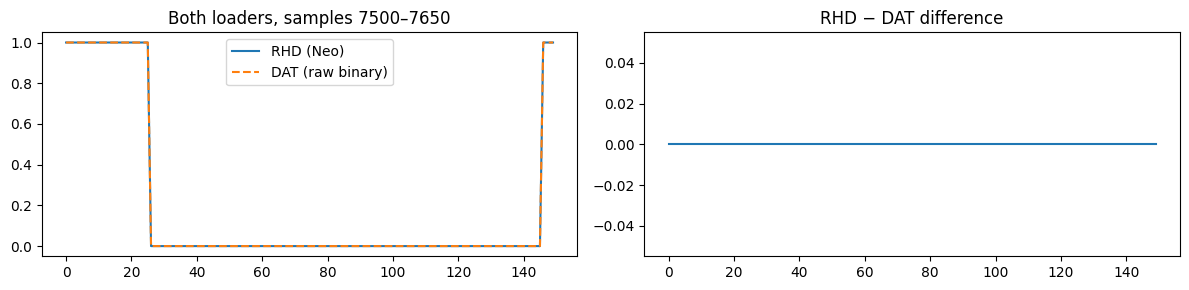

In [21]:
start_rhd = loader_rhd.time_to_sample(trial_start)
start_dat = loader_dat.time_to_sample(trial_start)

rhd_chunk = loader_rhd[start_rhd + OFFSET : start_rhd + OFFSET + WIN]
dat_chunk = loader_dat[start_dat + OFFSET : start_dat + OFFSET + WIN]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(rhd_chunk, label="RHD (Neo)")
axes[0].plot(dat_chunk, ls="--", label="DAT (raw binary)")
axes[0].set_title(f"Both loaders, samples {OFFSET}–{OFFSET+WIN}")
axes[0].legend()
axes[1].plot(rhd_chunk - dat_chunk)
axes[1].set_title("RHD − DAT difference")
plt.tight_layout()
plt.show()

## Test 2 — what is the actual pulse period?
Autocorrelation on the first 3000 samples. Uses `argrelextrema` to find local maxima
(avoids the lag=1 trap where adjacent-sample correlation is always highest).

Phase shift after 50 cycles: -4 samples
Implied true period: 149.9200 samples


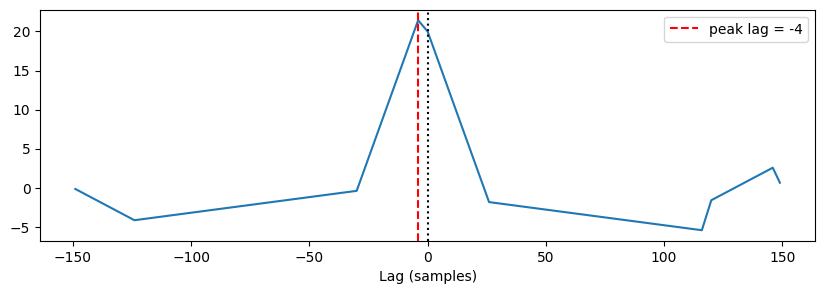

In [33]:
OFFSET = 7500
WIN = 150

pulse_0  = loader[start        : start + WIN       ].squeeze().astype(np.float64)
pulse_50 = loader[start+OFFSET : start+OFFSET + WIN].squeeze().astype(np.float64)
pulse_0  -= pulse_0.mean()
pulse_50 -= pulse_50.mean()

xc = np.correlate(pulse_50, pulse_0, mode="full")
lags = np.arange(-(WIN-1), WIN)
peak_lag = lags[np.argmax(xc)]

print(f"Phase shift after {OFFSET//WIN} cycles: {peak_lag} samples")
print(f"Implied true period: {WIN + peak_lag/50:.4f} samples")

plt.figure(figsize=(10, 3))
plt.plot(lags, xc)
plt.axvline(peak_lag, color="r", ls="--", label=f"peak lag = {peak_lag}")
plt.axvline(0, color="k", ls=":")
plt.xlabel("Lag (samples)")
plt.legend()
plt.show()


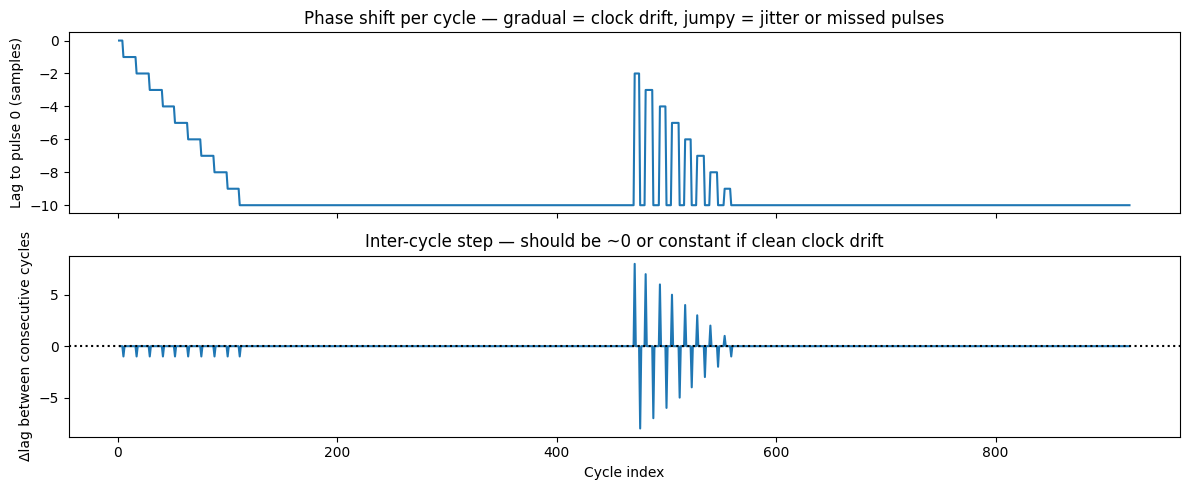

Drift rate: -0.0036 samples/cycle  (linear fit)
True period estimate: 149.9964 samples


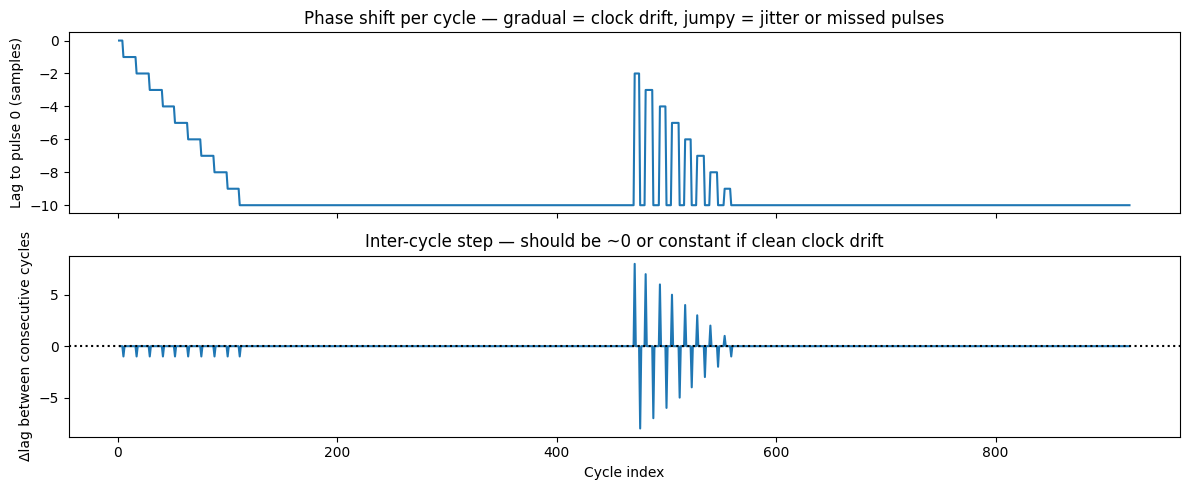

Drift rate: -0.0036 samples/cycle  (linear fit)
True period estimate: 149.9964 samples


In [ ]:
WIN = 150
pulse_0 = loader[start : start + WIN].squeeze().astype(np.float64)
pulse_0 -= pulse_0.mean()

lags_over_time = []
n_cycles = (end - start) // WIN

for i in range(1, n_cycles):
    expected_pos = start + i * WIN
    # search ±10 samples around expected position to catch drift
    lo = expected_pos - 10
    hi = expected_pos + WIN + 10
    chunk = loader[lo : hi].squeeze().astype(np.float64)
    chunk -= chunk.mean()
    xc = np.correlate(chunk, pulse_0, mode="valid")
    peak = int(np.argmax(xc)) - 10  # offset back to lag space
    lags_over_time.append(peak)

lags_over_time = np.array(lags_over_time)
cycles = np.arange(1, len(lags_over_time) + 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(cycles, lags_over_time)
axes[0].set_ylabel("Lag to pulse 0 (samples)")
axes[0].set_title("Phase shift per cycle — gradual = clock drift, jumpy = jitter or missed pulses")

axes[1].plot(cycles[1:], np.diff(lags_over_time))
axes[1].axhline(0, color="k", ls=":")
axes[1].set_xlabel("Cycle index")
axes[1].set_ylabel("Δlag between consecutive cycles")
axes[1].set_title("Inter-cycle step — should be ~0 or constant if clean clock drift")

plt.tight_layout()
plt.show()